### Opzione 1: Analisi Esplorativa (EDA) - Ti consiglio questa

Prima di qualsiasi altra cosa, dobbiamo capire i dati. Creiamo un notebook 01_EDA_heart_disease.ipynb dove:

- Esploriamo la struttura di X e y
- Controlliamo quanti missing values ci sono realmente
- Visualizziamo distribuzioni (età, colesterolo, etc.)
- Guardiamo la correlazione tra feature
- Analizziamo il target: quanti casi 0, 1, 2, 3, 4?
- distribuzione malati/non malati

### Opzione 2: Preprocessing diretto

Se vuoi andare subito al sodo, possiamo iniziare a:

- Gestire i valori mancanti
- Codificare le variabili categoriche
- Normalizzare/standardizzare
- Preparare i dati per l'algoritmo

### Opzione 3: Implementazione primo algoritmo

Se non vedi l'ora di scrivere codice, possiamo iniziare a implementare:

- La classe per K-NN o per l'Albero di Decisione
- Poi tornare al preprocessing quando serve

# 1 Initial Setup
Import all relevant libraries to do EDA (Exploratory Data Analysis).

We can see how dataset is made.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 

# fetch dataset
heart_disease = fetch_ucirepo(id=45) 

# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

# metadata
print("METADATA")
print(heart_disease.metadata) 

# variable information
print("\nVARIABLES")
print(heart_disease.variables)

print("\nFEATURES")
print(X)

print("\nTARGETS")
print(y)

METADATA
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Stei

## 1.1 Data Distribution
The follow schema show us relevat information, describing the number of data (so we can see nullable values), mean, std, min/max values and distribution.

In [3]:
df = pd.concat([X, y], axis=1)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 1.1.1 Nullable values
Here we can actually see what are the nullable feature. 

Those data are relevt to decide how to traet them in second therm.

In [56]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

### INFO

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## 1.2 Bivariate Analysis
We can see how data works together. Sometimes we can see some intresting patterns between data.

<Figure size 1000x600 with 0 Axes>

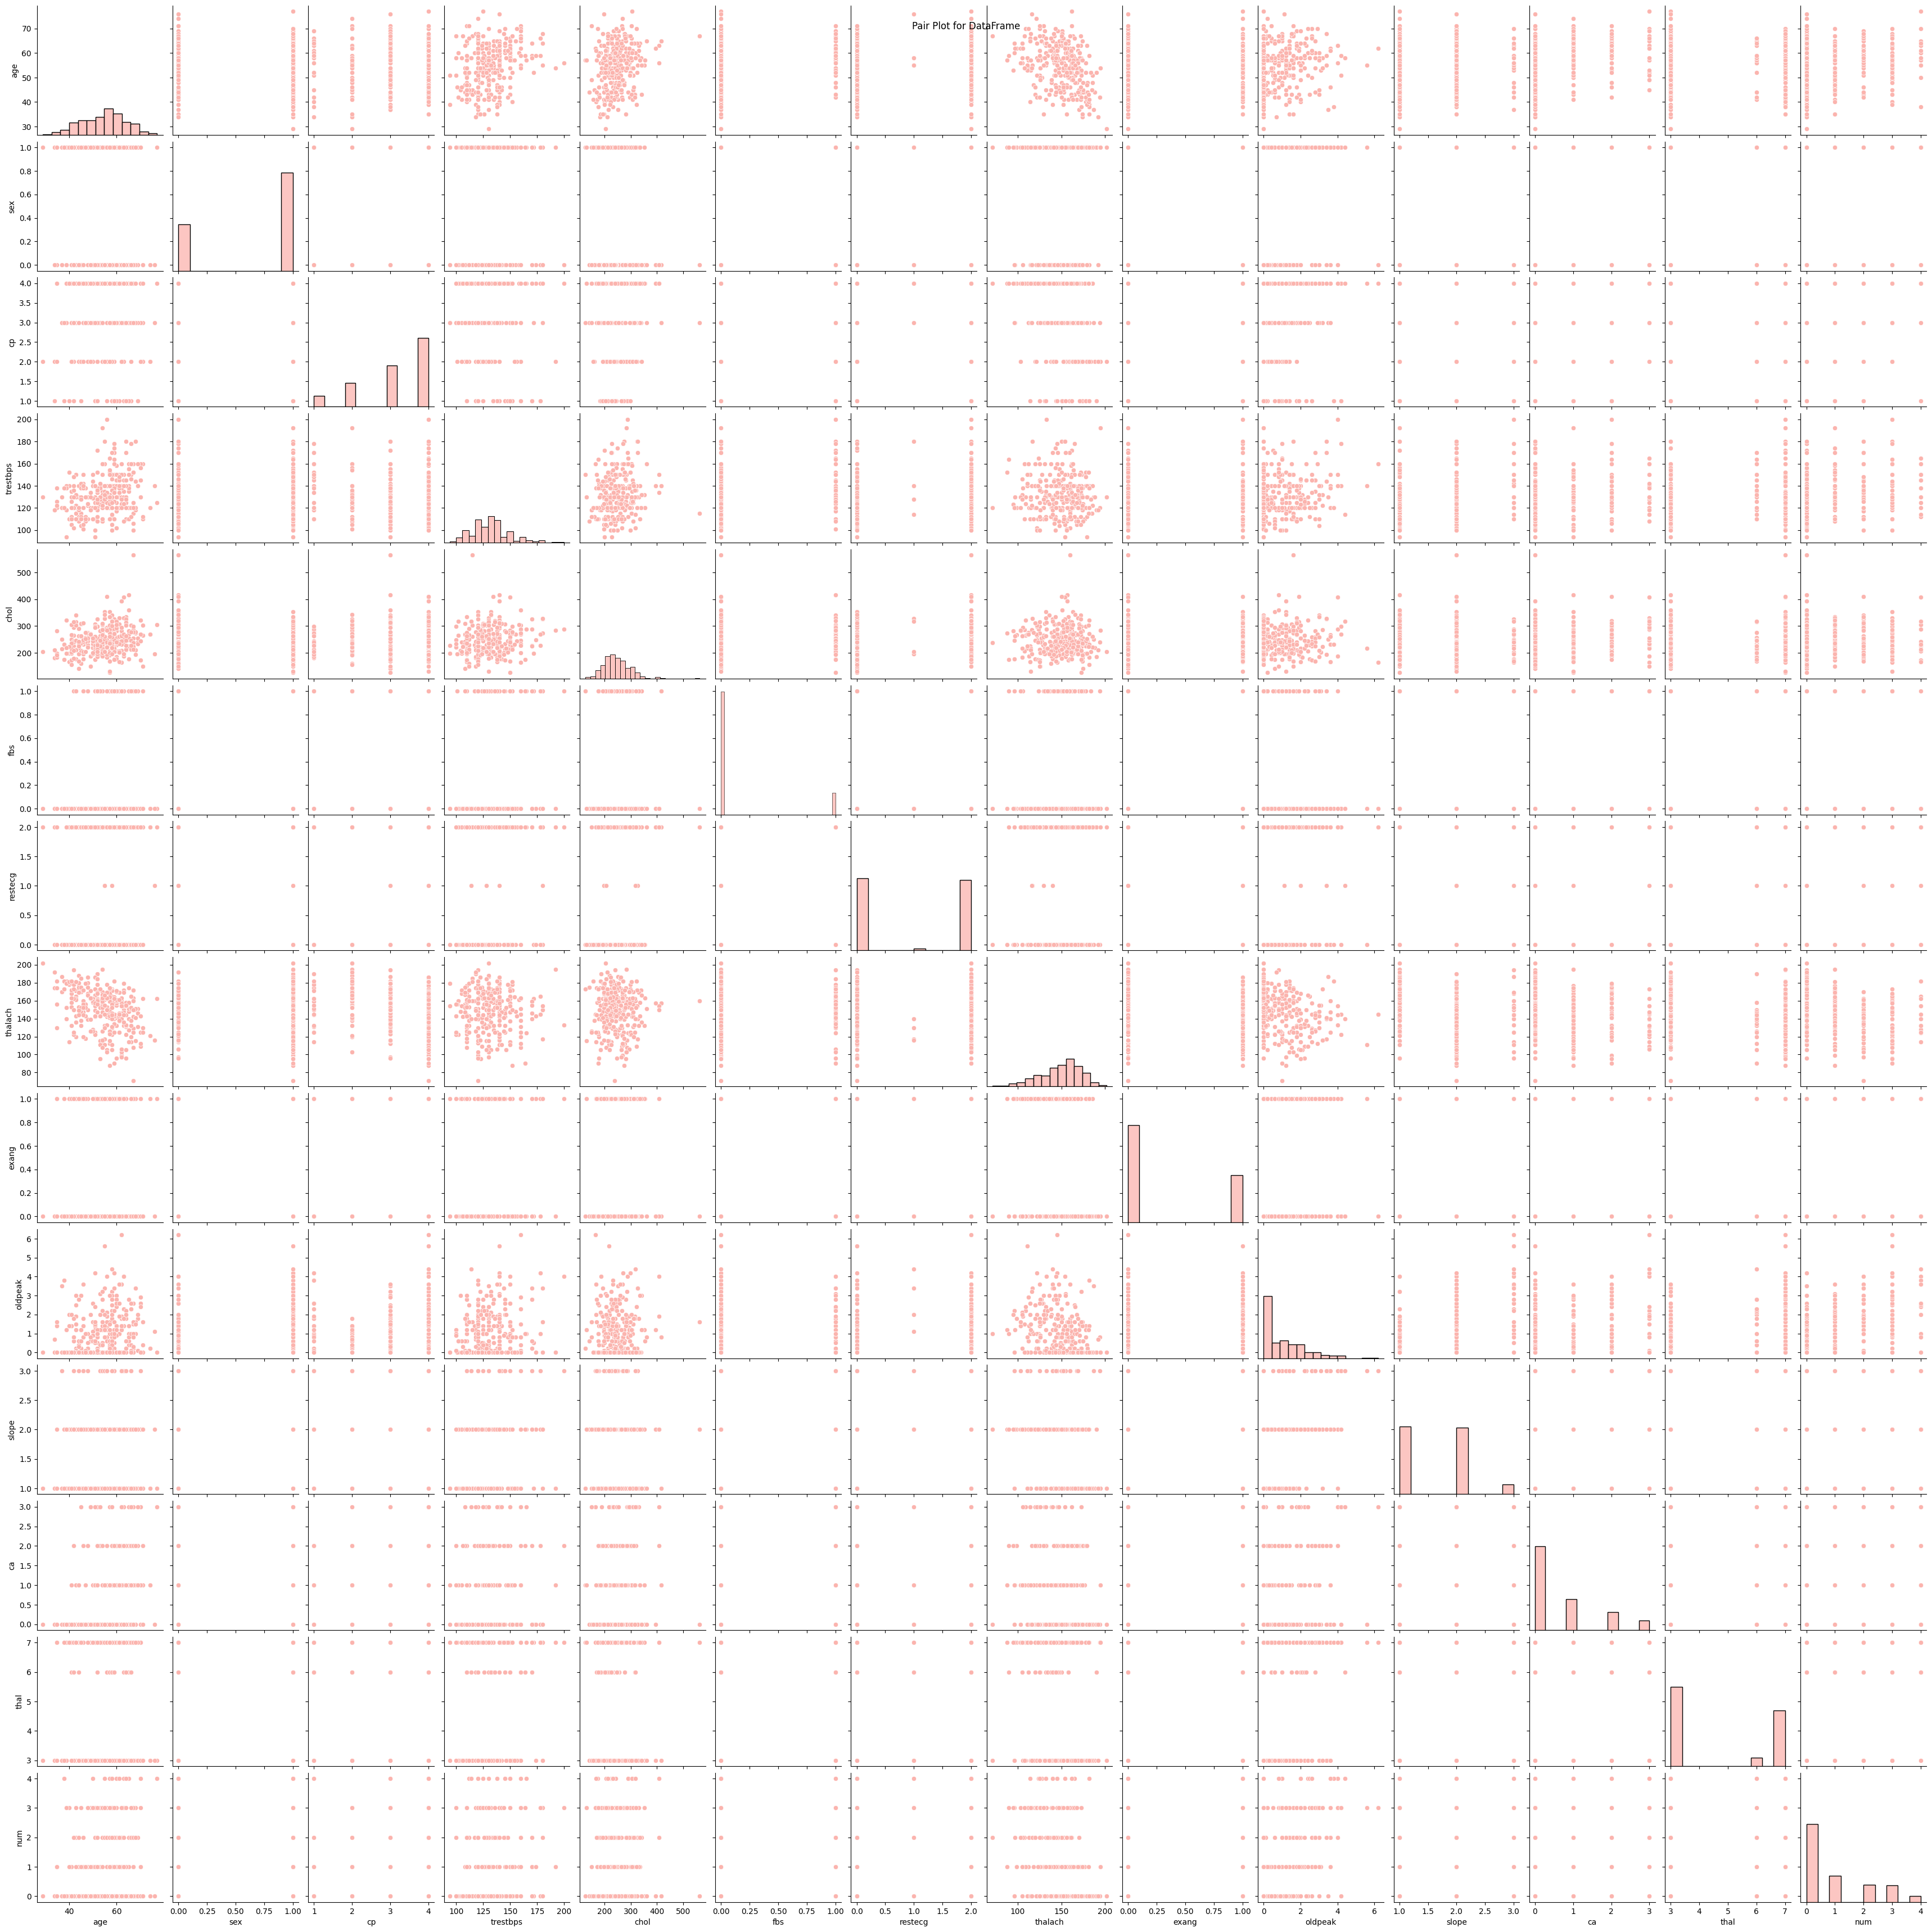

In [4]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

<Axes: >

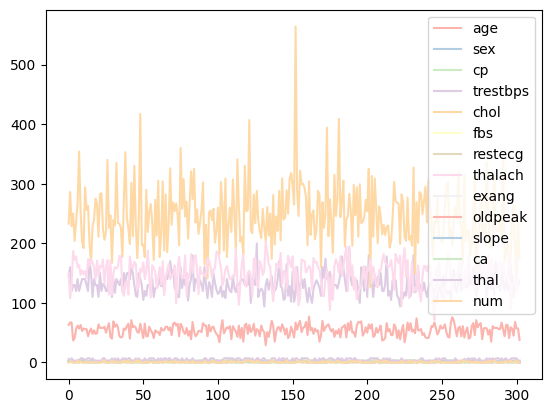

In [19]:
df.plot()

# Osservazione
Avere un dataset con distribuzione simile di valori

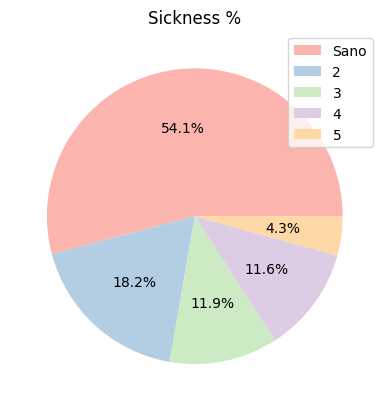

In [47]:
sick_pie=df['num'].value_counts()
sick_pie.plot.pie(labels=None, autopct='%1.1f%%')
plt.title('Sickness %')
plt.legend(['Sano', '2', '3', '4', '5'])

Text(0.5, 1.0, 'Correlazione tra le variabili')

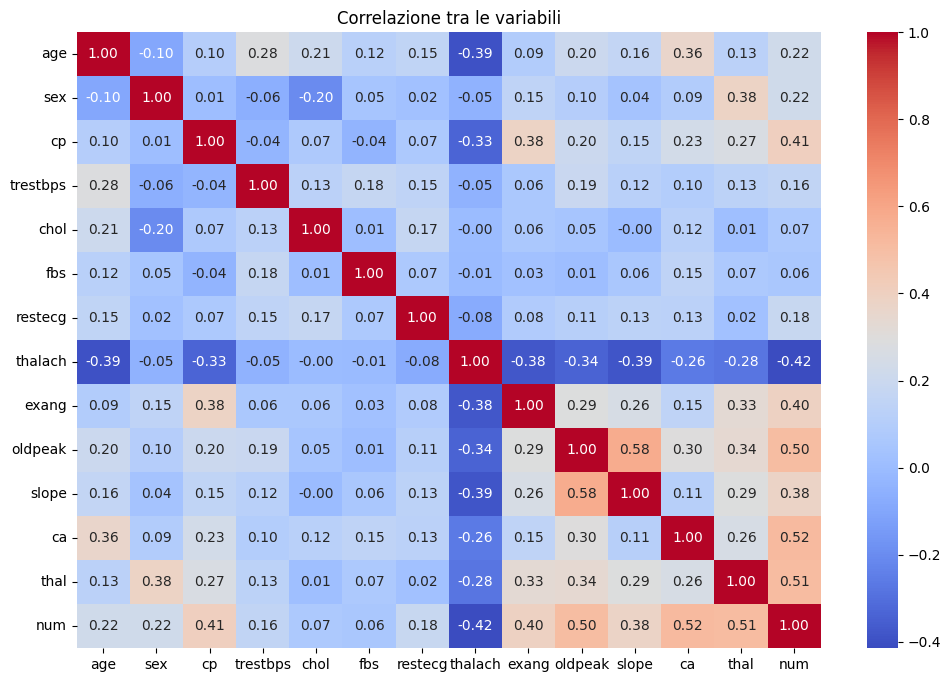

In [48]:
plt.figure(figsize=(12, 8))
sns.heatmap(pd.concat([X, y], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlazione tra le variabili')

Text(0.5, 1.0, "Distribuzione dell'Età per diagnosi (0=Sano, 1-4=Malato)")

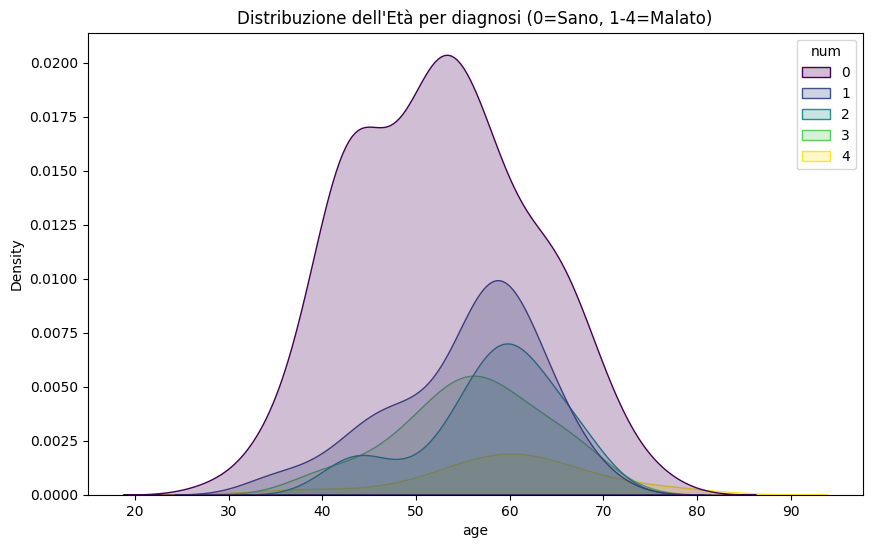

In [49]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=pd.concat([X, y], axis=1), x='age', hue='num', fill=True, palette='viridis')
plt.title('Distribuzione dell\'Età per diagnosi (0=Sano, 1-4=Malato)')

Text(0.5, 1.0, 'Età vs Battito Cardiaco Massimo')

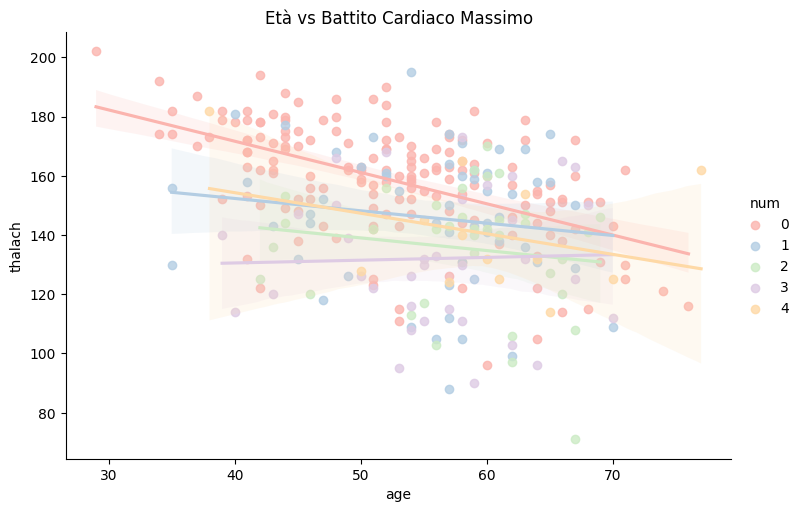

In [50]:
sns.lmplot(data=pd.concat([X, y], axis=1), x='age', y='thalach', hue='num', aspect=1.5)
plt.title('Età vs Battito Cardiaco Massimo')

/var/folders/sr/4rx90q7s2pd8_x4hnl6jpqvm0000gn/T/ipykernel_1661/954578330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=y['num'], y=X['chol'], palette='Set2')
/var/folders/sr/4rx90q7s2pd8_x4hnl6jpqvm0000gn/T/ipykernel_1661/954578330.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x=y['num'], y=X['trestbps'], palette='Set3')


Text(0.5, 1.0, 'Pressione a Riposo per Stato di Salute')

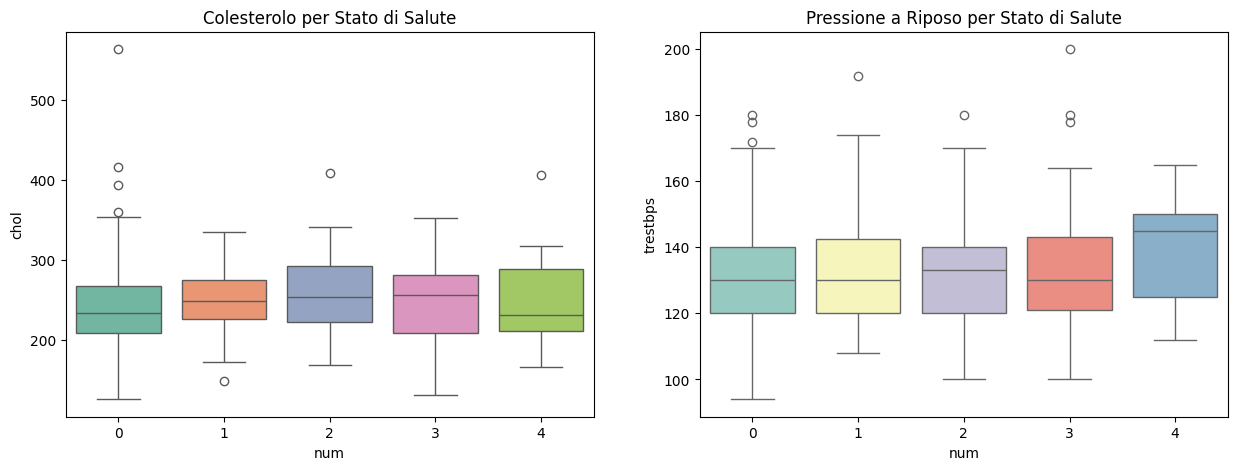

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(ax=axes[0], x=y['num'], y=X['chol'], palette='Set2')
axes[0].set_title('Colesterolo per Stato di Salute')

sns.boxplot(ax=axes[1], x=y['num'], y=X['trestbps'], palette='Set3')
axes[1].set_title('Pressione a Riposo per Stato di Salute')

Text(0.5, 1.0, 'Tipo di Dolore Toracico vs Diagnosi')

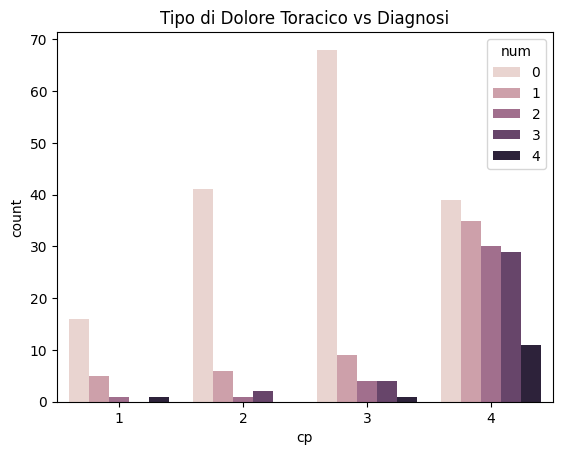

In [52]:
sns.countplot(data=pd.concat([X, y], axis=1), x='cp', hue='num')
plt.title('Tipo di Dolore Toracico vs Diagnosi')

In [80]:
# Crea una maschera booleana: True per le righe con almeno un nullo
rows_with_nan = X[X.isnull().any(axis=1)]

# Stampa il risultato
print("Righe con valori mancanti:")
print(rows_with_nan)

# Calcola la moda (restituisce una Serie, quindi prendiamo il primo elemento [0])
moda_ca = X['ca'].mode()[0]

print(f"La moda della colonna 'ca' è: {moda_ca}")

# Sostituisci i valori nulli con la moda
X['ca'] = X['ca'].fillna(moda_ca)

print("Valori nulli rimasti in 'ca':", X['ca'].isnull().sum())

# Sistema anche thal già che ci sei
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

Righe con valori mancanti:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
266   52    1   4       128   204    1        0      156      1      1.0   

     slope   ca  thal  
87       1  0.0   NaN  
266      2  0.0   NaN  
La moda della colonna 'ca' è: 0.0
Valori nulli rimasti in 'ca': 0


# Sostituzione valori nulli
Pagina 243 libro di simo